In [8]:
##### Calculates raster of relative wealth percentile within each country 

import os
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from pathlib import Path
import rasterstats
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show, plotting_extent
import matplotlib.pyplot as plt
from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt
import math
from rasterio.transform import from_bounds
import glob
from scipy import ndimage
from matplotlib import gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import rioxarray
from scipy.signal import savgol_filter
import rasterio.features
from rasterio.enums import Resampling

In [4]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent 

# country geographies 
countries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer="ADM_0")
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# reference raster
ref_path_reprojected = f"{cd}/Results/Raster_model/reprojected/terrain_slope.tif"

# relative wealth directory
wealth_dir = f'{cd}/Data/Raw/Chi_relative_wealth/individual/'

# rasters
wealth = f'{cd}/Data/Raw/Chi_relative_wealth/relative_wealth_index_LMIC.tif'
population = f"{cd}/Data/Raw/Predictors/Population_Bondarenko/total_pop_2020_resampled_reprojected.tif"

# save paths
wealth_path = f"{cd}/Data/Raw/Chi_relative_wealth/relative_wealth_index_LMIC_resampled.tif"
wealth_path_final = f"{cd}/Data/Raw/Chi_relative_wealth/relative_wealth_index_LMIC_resampled_filled.tif"

percentiles = f"{cd}/Data/Clean/GDP_percentiles/relative_wealth_percentiles.tif"

In [3]:
##### Reconstruct relative wealth raster from CSV (all countries combined)

EARTH_RADIUS = 6378137.0

def tile_to_merc(x, y, zoom):
    world_size = 2 * math.pi * EARTH_RADIUS
    tile_size = world_size / (2 ** zoom)
    mx = -math.pi * EARTH_RADIUS + x * tile_size
    my = math.pi * EARTH_RADIUS - y * tile_size
    return mx, my

def deg2tilexy(lat_deg, lon_deg, zoom):
    lat_rad = math.radians(lat_deg)
    n = 2 ** zoom
    x = int((lon_deg + 180.0) / 360.0 * n)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return x, y

ZOOM = 14  # Meta RWI tiles are zoom-14 Bing tiles

# --- read + combine every country CSV in the folder ---
csv_paths = glob.glob(os.path.join(wealth_dir, "*.csv"))
print(f"Found {len(csv_paths)} country CSVs")

dfs = [pd.read_csv(p) for p in csv_paths]
df = pd.concat(dfs, ignore_index=True)

# derive tile x/y straight from lat/lon
tiles = df.apply(lambda r: deg2tilexy(r["latitude"], r["longitude"], ZOOM), axis=1)
df["tile_x"], df["tile_y"] = zip(*tiles)
df["zoom"] = ZOOM

# drop exact duplicate tiles (border points can appear in more than one country's file)
before = len(df)
df = df.drop_duplicates(subset=["tile_x", "tile_y"], keep="first")
print(f"Dropped {before - len(df)} duplicate tiles across country files")

zoom = ZOOM
x_min, x_max = df["tile_x"].min(), df["tile_x"].max()
y_min, y_max = df["tile_y"].min(), df["tile_y"].max()

width = x_max - x_min + 1
height = y_max - y_min + 1

raster = np.full((height, width), -9999.0, dtype=np.float32)
row_idx = df["tile_y"] - y_min
col_idx = df["tile_x"] - x_min
raster[row_idx.to_numpy(), col_idx.to_numpy()] = df["rwi"].to_numpy()

west, north = tile_to_merc(x_min, y_min, zoom)
east, south = tile_to_merc(x_max + 1, y_max + 1, zoom)

transform = from_bounds(west, south, east, north, width, height)

with rasterio.open(
    wealth, "w", driver="GTiff",
    height=height, width=width, count=1,
    dtype=raster.dtype, crs="EPSG:3857",
    transform=transform, nodata=-9999.0,
) as dst:
    dst.write(raster, 1)

print(f"Wrote {wealth}: {width}x{height} px, zoom={zoom}, "
      f"{df.shape[0]} of {width*height} cells populated")

Found 107 country CSVs
Dropped 5091 duplicate tiles across country files
Wrote /Users/carinamanitius/Documents/GitHub/AgDownscaling/Data/Raw/Chi_relative_wealth/relative_wealth_index_LMIC.tif: 11749x6051 px, zoom=14, 2752275 of 71093199 cells populated


In [4]:
##### Resample RWI raster

with rasterio.open(ref_path_reprojected) as ref:
    ref_profile = ref.profile
    dst_crs = ref.crs
    dst_transform = ref.transform
    dst_width = ref.width
    dst_height = ref.height

with rasterio.open(wealth) as src:
    src_data = src.read(1)
    src_transform = src.transform
    src_crs = src.crs
    src_nodata = src.nodata  # -9999.0 from the previous step

dst_nodata = -9999.0
dst_data = np.full((dst_height, dst_width), dst_nodata, dtype=np.float32)

reproject(
    source=src_data,
    destination=dst_data,
    src_transform=src_transform,
    src_crs=src_crs,
    src_nodata=src_nodata,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    dst_nodata=dst_nodata,
    resampling=Resampling.average,
)

out_profile = ref_profile.copy()
out_profile.update(count=1, dtype="float32", nodata=dst_nodata)

with rasterio.open(wealth_path, "w", **out_profile) as dst:
    dst.write(dst_data, 1)

print(f"Wrote {wealth_path}: {dst_width}x{dst_height} px, matching {ref_path_reprojected}")

Wrote /Users/carinamanitius/Documents/GitHub/AgDownscaling/Data/Raw/Chi_relative_wealth/relative_wealth_index_LMIC_resampled.tif: 3607x1768 px, matching /Users/carinamanitius/Documents/GitHub/AgDownscaling/Results/Raster_model/reprojected/terrain_slope.tif


In [3]:
##### Fill missing data in RWI (only for countries with RWI data) — simplified, faster version

countries = countries.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='left')

with rasterio.open(wealth_path) as src:
    wealth_data = src.read(1)
    wealth_nodata = src.nodata
    profile = src.profile
    raster_crs = src.crs
    raster_transform = src.transform
    height, width = wealth_data.shape

with rasterio.open(ref_path_reprojected) as ref:
    ref_data = ref.read(1)
    ref_nodata = ref.nodata

missing_mask = (wealth_data == wealth_nodata) | np.isnan(wealth_data)
ref_valid_mask = ~((ref_data == ref_nodata) | np.isnan(ref_data)) if ref_nodata is not None else ~np.isnan(ref_data)

gdf_r = countries.to_crs(raster_crs).reset_index(drop=True)

# rasterize a binary RWI_data mask directly: 1 where country has RWI data, 0 elsewhere
shapes_rwi = ((geom, 1) for geom, has_rwi in zip(gdf_r.geometry, gdf_r["RWI_data"]) if has_rwi == 1)
rwi_mask = rasterize(shapes_rwi, out_shape=(height, width),
                      transform=raster_transform, fill=0, dtype="uint8").astype(bool)

need_fill_mask = rwi_mask & missing_mask & ref_valid_mask
candidate_mask = rwi_mask & ~missing_mask

filled_data = wealth_data.copy()

idx = distance_transform_edt(~candidate_mask, return_distances=False, return_indices=True)
nearest_vals = filled_data[tuple(idx)]
filled_data[need_fill_mask] = nearest_vals[need_fill_mask]

out_profile = profile.copy()
out_profile.update(dtype="float32", nodata=wealth_nodata)

with rasterio.open(wealth_path_final, "w", **out_profile) as dst:
    dst.write(filled_data.astype("float32"), 1)

print(f"Wrote {wealth_path_final}")

Wrote /Users/carinamanitius/Documents/GitHub/AgDownscaling/Data/Raw/Chi_relative_wealth/relative_wealth_index_LMIC_resampled_filled.tif


In [6]:
##### Create percentile raster for relative wealth (country)
# Step 1: calculate CDF of relative wealth by population (excluding filled in pixels)
# Step 2: assign pixels to country-specific percentiles based on CDF of relative wealth in country

#### RWI IS NATIONALLY DEFINED SO CAN'T DO GLOBAL 

def value_percentile_raster(pop_arr, pop_nodata, value_path, ref_path, countries_gdf,
                             out_path=None, invert=False, exclude_mask=None):
    with rasterio.open(ref_path) as ref:
        transform, shape, crs = ref.transform, ref.shape, ref.crs

    with rasterio.open(value_path) as src:
        value = src.read(1).astype(np.float64)
        value_nodata = src.nodata

    countries_gdf = countries_gdf.to_crs(crs).reset_index(drop=True)
    countries_gdf["_cid"] = np.arange(1, len(countries_gdf) + 1)

    country_raster = rasterize(
        list(zip(countries_gdf.geometry, countries_gdf["_cid"])),
        out_shape=shape, transform=transform, fill=0, dtype="int32",
    )

    pop = pop_arr.astype(np.float64)

    # nodata-safe masks (handles both NaN nodata and sentinel-value nodata like -9999)
    if value_nodata is not None and not np.isnan(value_nodata):
        valid_val = ~np.isnan(value) & (value != value_nodata)
    else:
        valid_val = ~np.isnan(value)

    if pop_nodata is not None and not np.isnan(pop_nodata):
        has_pop = ~np.isnan(pop) & (pop != pop_nodata) & (pop > 0)
    else:
        has_pop = ~np.isnan(pop) & (pop > 0)

    base_valid = has_pop & valid_val
    # pixels used to build the CDF (step 1) can optionally exclude filled-in pixels,
    # while assignment (step 2) still covers all base_valid pixels
    cdf_valid = base_valid & (~exclude_mask if exclude_mask is not None else True)

    percentile_raster = np.full(shape, np.nan, dtype=np.float32)

    for cid in np.unique(country_raster):
        if cid == 0:
            continue
        country_mask = country_raster == cid
        rows, cols = np.where(country_mask)
        rmin, rmax, cmin, cmax = rows.min(), rows.max(), cols.min(), cols.max()

        sl = np.s_[rmin:rmax+1, cmin:cmax+1]
        sub_mask   = country_mask[sl]
        sub_value  = value[sl]
        sub_pop    = pop[sl]
        sub_base   = base_valid[sl] & sub_mask
        sub_cdf    = cdf_valid[sl] & sub_mask

        # no-data countries (or countries with zero valid pixels) are simply skipped,
        # leaving percentile_raster as NaN for every pixel in that country
        if not sub_cdf.any():
            continue

        w_val = sub_value[sub_cdf]
        w_pop = sub_pop[sub_cdf]

        order = np.argsort(w_val)
        sorted_val, sorted_pop = w_val[order], w_pop[order]

        unique_vals, inverse = np.unique(sorted_val, return_inverse=True)
        pop_per_val = np.zeros(len(unique_vals))
        np.add.at(pop_per_val, inverse, sorted_pop)

        cum_pop = np.cumsum(pop_per_val)
        total_pop = cum_pop[-1]
        midpoint_share = (cum_pop - pop_per_val / 2.0) / total_pop
        pct_int = np.clip(np.ceil(midpoint_share * 100), 1, 100)

        if invert:
            pct_int = 101 - pct_int   # highest value -> 0(ish), lowest value -> 100

        if not sub_base.any():
            continue

        assigned = np.interp(sub_value[sub_base], unique_vals, pct_int)
        assigned = np.clip(np.round(assigned), 1, 100).astype(np.float32)

        out_sub = percentile_raster[sl]
        out_sub[sub_base] = assigned
        percentile_raster[sl] = out_sub

    out_meta = dict(driver="GTiff", height=shape[0], width=shape[1], count=1,
                     dtype="float32", crs=crs, transform=transform, nodata=np.nan)

    if out_path:
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(percentile_raster, 1)

    return percentile_raster

# re-read pop raster (with its nodata)
with rasterio.open(population) as src:
    pop_PA = src.read(1)
    pop_nodata = src.nodata

rel_dep_pctl = value_percentile_raster(
    pop_PA,
    pop_nodata,
    wealth_path_final,
    ref_path_reprojected,
    countries,
    out_path=percentiles,
    invert=False,
)

In [9]:
##### Load data

# capital rasters
capital = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif"

# labor rasters
labor = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif"

# production raster
production = f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif"

# priority rasters
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"

# country boundaries 
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/priority_areas"

In [12]:
##### Load + align rasters

capital_da         = rioxarray.open_rasterio(capital, masked=True)
labor_da            = rioxarray.open_rasterio(labor, masked=True)
wealth_national_da  = rioxarray.open_rasterio(percentiles, masked=True)
biodiversity_da     = rioxarray.open_rasterio(biodiversity_with_PA, masked=True)
production_da       = rioxarray.open_rasterio(production, masked=True)

percentile_lookup = {'national': wealth_national_da, 'global': wealth_national_da}


In [11]:
##### Define key functions

def pct_by_percentile_within_mask(var_da, pctl_da, priority_mask):
    """% of the mask total for var, broken out by GDP-pc percentile (1-100)."""
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)
    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = (~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100)
             & priority_mask)

    var_v  = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum().reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100 if total > 0 else grouped


def smooth(series, window=9, polyorder=2):
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)


COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#6B7280",
}

country_mask_cache = {}

def get_country_mask(gid0, target_da=wealth_national_da):
    """Rasterize a single country's outline onto the common reference grid."""
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

    country_mask_cache[gid0] = mask
    return mask


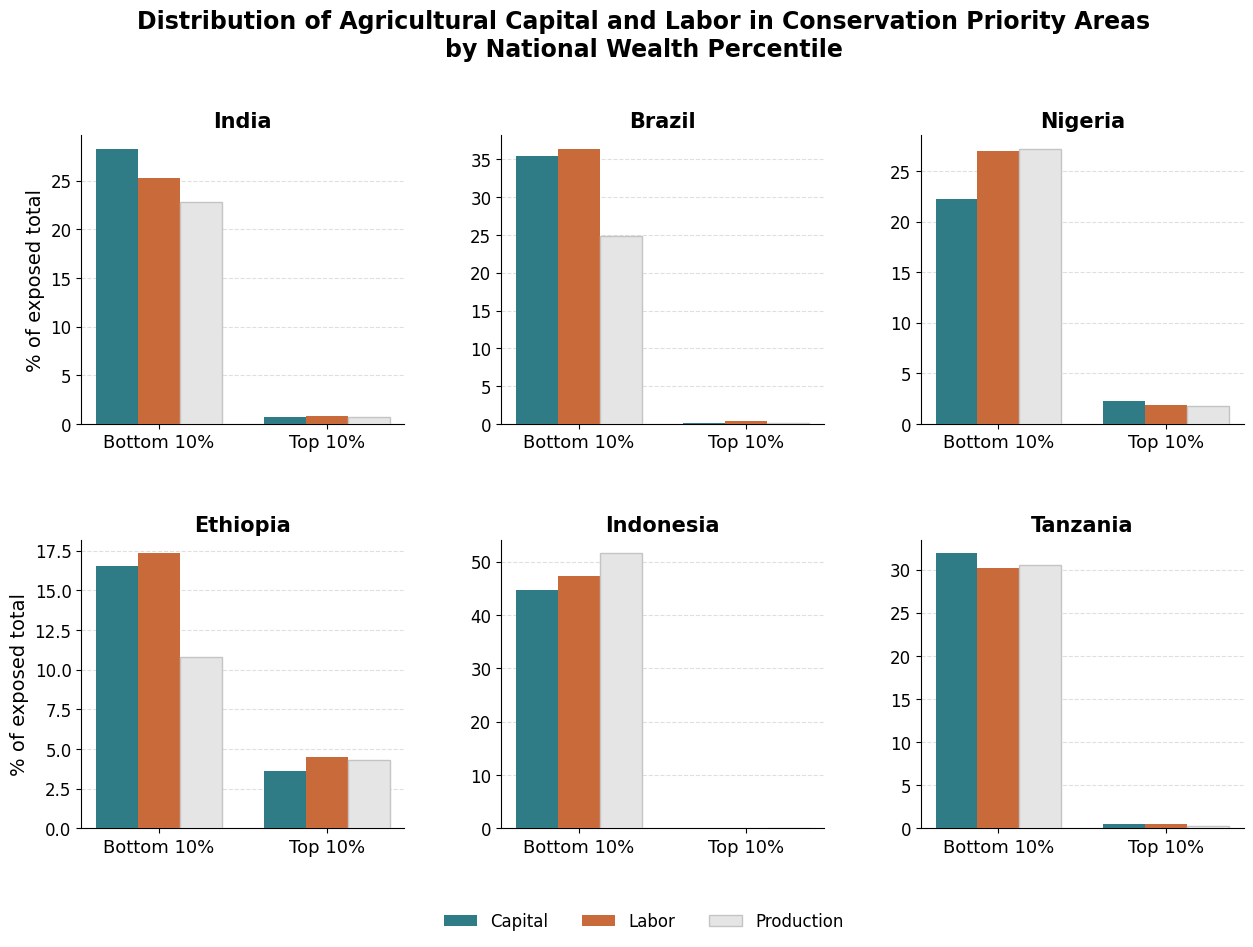

In [14]:
#### PLOT FOR 6 COUNTRIES

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#E5E5E5",
}
PRODUCTION_EDGE = "#C4C4C4"

def plot_capital_labor_exposure_grid(
    countries=("CHN", "IND", "USA", "BRA", "NGA", "IDN"),
    country_names=None,
    country_percentile_scope='national',
    save=True,
):
    if country_names is None:
        country_names = {}

    priority_da = biodiversity_da
    priority_mask_full = priority_da.squeeze().values >= 1

    def build_mask(gid0):
        mask = get_country_mask(gid0) & priority_mask_full
        return mask

    percentile_groups = {
        "Bottom 10%": range(1, 11),
        "Top 10%": range(91, 101),
    }
    group_names = list(percentile_groups.keys())
    x = np.arange(len(group_names))
    width = 0.25

    def draw_bar_panel(ax, capital_vals, labor_vals, production_vals, title):
        ax.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3, label="Capital")
        ax.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3, label="Labor")
        ax.bar(x + width, production_vals, width, color=COLORS["Production"],
               edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3, label="Production")

        ax.set_xticks(x)
        ax.set_xticklabels(group_names, fontsize=13)
        ax.tick_params(axis="y", labelsize=12)
        ax.set_title(title, fontweight="bold", fontsize=15)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

    pctl_da_country = percentile_lookup[country_percentile_scope]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for ax, gid0 in zip(axes, countries):
        country_mask = build_mask(gid0)

        capital_pct    = pct_by_percentile_within_mask(capital_da, pctl_da_country, country_mask)
        labor_pct      = pct_by_percentile_within_mask(labor_da, pctl_da_country, country_mask)
        production_pct = pct_by_percentile_within_mask(production_da, pctl_da_country, country_mask)

        capital_vals    = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        labor_vals      = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        production_vals = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

        panel_title = country_names.get(gid0, gid0)
        draw_bar_panel(ax, capital_vals, labor_vals, production_vals, panel_title)

    # shared y-label on left-column panels only
    for ax in (axes[0], axes[3]):
        ax.set_ylabel("% of exposed total", fontsize=14)

    handles = [
        Patch(facecolor=COLORS["Capital"], label="Capital"),
        Patch(facecolor=COLORS["Labor"], label="Labor"),
        Patch(facecolor=COLORS["Production"], edgecolor=PRODUCTION_EDGE, label="Production"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=12)

    fig.suptitle("Distribution of Agricultural Capital and Labor in Conservation Priority Areas\nby National Wealth Percentile",
                 fontweight="bold", fontsize=17, y=1.02)

    fig.subplots_adjust(wspace=0.3, hspace=0.4)

    if save:
        plt.savefig(f"{fd}/exposure_priority_wealth.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig

# Plot
plot_capital_labor_exposure_grid(
    countries=("IND", "BRA", "NGA", "ETH", "IDN", "TZA"),
    country_names={"IND": "India", "BRA": "Brazil", "NGA": "Nigeria",
                   "ETH": "Ethiopia", "IDN": "Indonesia", "TZA": "Tanzania"},
);